# Repartir por igual no es lo mismo que repartir con justicia

Dar a todos la misma porción de un bien compartido suena a lo más justo que se puede hacer.

Un modelo publicado en *Nature* (junio 2026) encontró lo contrario: en una red social, repartir por igual puede ser **el camino más rápido para que el beneficio se concentre en unos pocos muy conectados** — y aun así, sea la mejor forma de que la cooperación se contagie.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Sheng et al. (2026), *Cooperation conflicts with equality when allocating public goods*, Nature.
**DOI:** [10.1038/s41586-026-10550-3](https://doi.org/10.1038/s41586-026-10550-3)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-03-cooperation-equality-public-goods/notebook.ipynb)

> **Video:** [Ver en YouTube](https://youtube.com/shorts/fi0ObFVUD28)

## ¿De qué va esto?

El equipo construyó un modelo de teoría de juegos: personas conectadas en una red que deciden cooperar o no, y un bien público que hay que repartir. Probaron dos reglas de reparto:

- **Uniforme** — todos reciben la misma porción, sin importar cuánto aportan.
- **Equitativa** — cada quien recibe en proporción a lo que su posición puede aportar.

Luego corrieron el modelo sobre **50 redes sociales reales**, midiendo dos cosas en cada una: qué tan fácil se propaga la cooperación, y qué tan repartido queda el beneficio (con el coeficiente de Gini, donde 0 es igualdad total y 1 es desigualdad máxima).

La pregunta del paper: ¿la regla que ayuda a cooperar es también la que reparte con justicia? Veamos qué dicen los datos del modelo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_EQUITATIVA = '#2563EB'   # azul — reparto proporcional al aporte
COLOR_UNIFORME   = '#DC2626'   # rojo — reparto en partes iguales
COLOR_REFERENCIA = '#D97706'   # ámbar — umbrales / líneas guía
COLOR_CONTEXTO   = '#BBBBBB'   # gris — fondo
FUENTE = 'Fuente: Sheng et al. (2026), Nature | Datos: Zenodo (anzhisheng/cooperation-and-inequality)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 3 datasets (Figura 4 + Figura 2 izq/der del paper)
tradeoff = pd.read_csv('datos/tradeoff_heterogeneidad.csv')
red_A = pd.read_csv('datos/payoffs_red_A_left.csv')   # red dispersa
red_B = pd.read_csv('datos/payoffs_red_B_right.csv')  # red densa

print(f"Redes barridas:         {len(tradeoff)}")
print(f"Heterogeneidad (var σ²): {tradeoff.degree_variance.min():.1f}  a  {tradeoff.degree_variance.max():.1f}")
print(f"Gini equitativa:         máx {tradeoff.equitable_gini.max():.0e}  (esencialmente 0)")
print(f"Gini uniforme:           {tradeoff.uniform_gini.min():.3f}  a  {tradeoff.uniform_gini.max():.3f}")
print(f"Red A (dispersa): {len(red_A)} personas, grado medio {red_A.grado.mean():.1f}")
print(f"Red B (densa):    {len(red_B)} personas, grado medio {red_B.grado.mean():.1f}")

Redes barridas:         50
Heterogeneidad (var σ²): 29.1  a  186.1
Gini equitativa:         máx 1e-16  (esencialmente 0)
Gini uniforme:           0.100  a  0.330
Red A (dispersa): 50 personas, grado medio 2.0
Red B (densa):    50 personas, grado medio 9.4


Aquí está el costo escondido de repartir por igual.

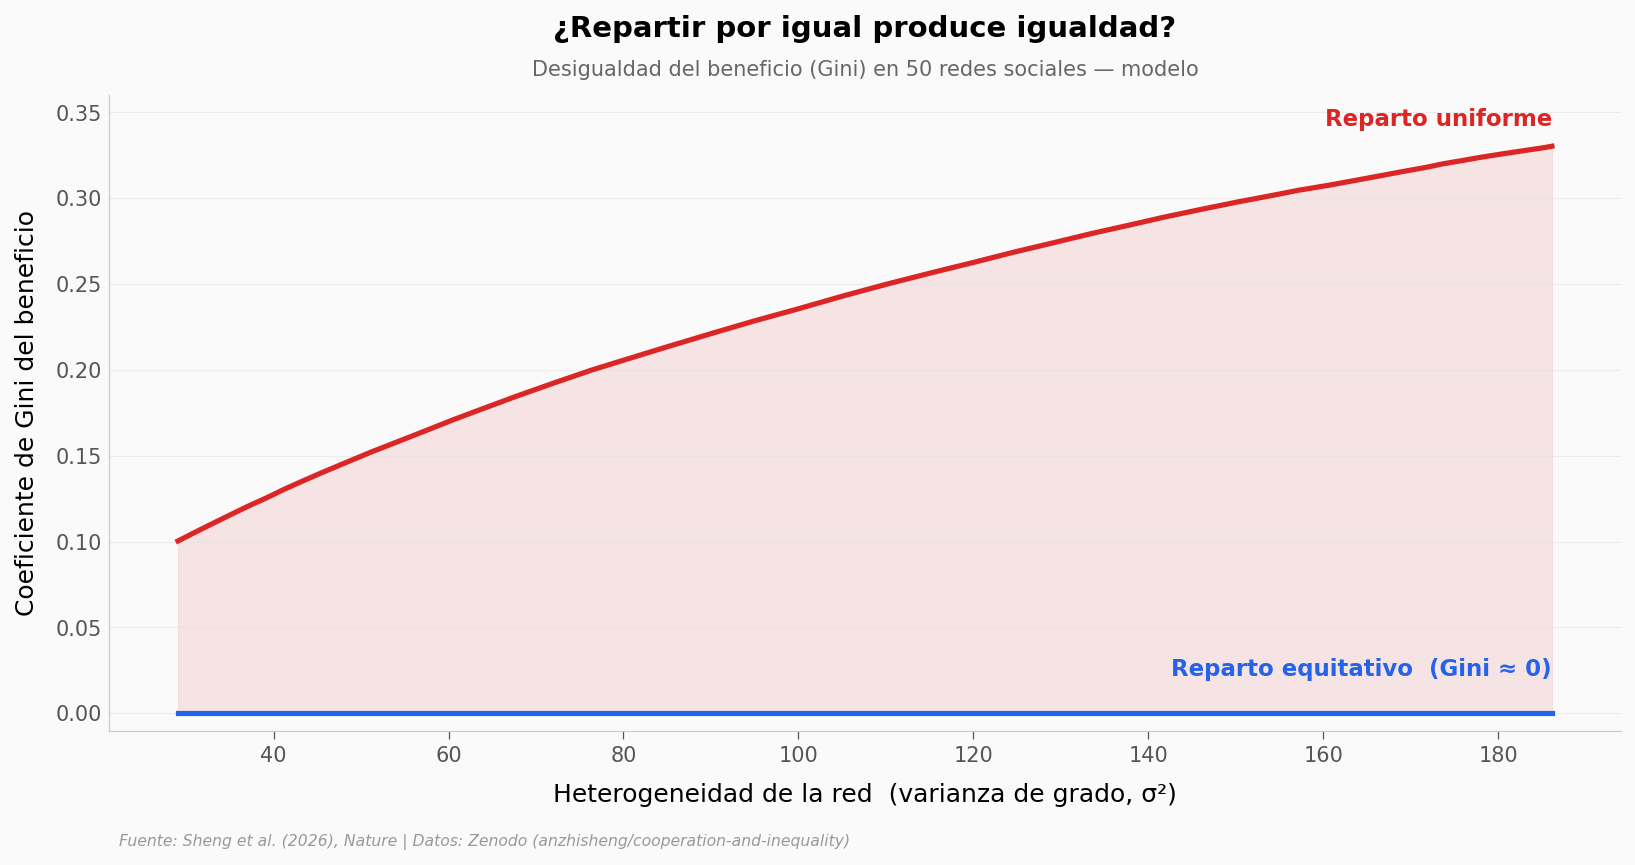

Reparto equitativo: Gini máximo 1e-16 en todo el rango.
Reparto uniforme:   Gini sube de 0.100 a 0.330 (3.3× con la heterogeneidad).


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = tradeoff.degree_variance
ax.plot(x, tradeoff.uniform_gini, color=COLOR_UNIFORME, linewidth=2.5, zorder=5)
ax.plot(x, tradeoff.equitable_gini, color=COLOR_EQUITATIVA, linewidth=2.5, zorder=5)

# Relleno = la desigualdad que añade repartir por igual
ax.fill_between(x, tradeoff.equitable_gini, tradeoff.uniform_gini,
                color=COLOR_UNIFORME, alpha=0.10, zorder=1)

# Inline labels (sin caja de leyenda)
ax.text(x.iloc[-1], tradeoff.uniform_gini.iloc[-1] + 0.012, 'Reparto uniforme',
        color=COLOR_UNIFORME, fontsize=11, fontweight='bold', ha='right')
ax.text(x.iloc[-1], 0.022, 'Reparto equitativo  (Gini ≈ 0)',
        color=COLOR_EQUITATIVA, fontsize=11, fontweight='bold', ha='right')

ax.set_title('¿Repartir por igual produce igualdad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Desigualdad del beneficio (Gini) en 50 redes sociales — modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Heterogeneidad de la red  (varianza de grado, σ²)')
ax.set_ylabel('Coeficiente de Gini del beneficio')
ax.set_ylim(-0.01, 0.36)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gini_vs_heterogeneidad.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Reparto equitativo: Gini máximo {tradeoff.equitable_gini.max():.0e} en todo el rango.")
print(f"Reparto uniforme:   Gini sube de {tradeoff.uniform_gini.min():.3f} a {tradeoff.uniform_gini.max():.3f} "
      f"({tradeoff.uniform_gini.max()/tradeoff.uniform_gini.min():.1f}× con la heterogeneidad).")

El reparto equitativo no se mueve: cuando cada quien recibe en proporción a su aporte, el beneficio queda igualado en cualquier red. El uniforme, en cambio, se dispara.

Y lo hace en función de la **heterogeneidad** — qué tan desigual es la red en sí misma. Cuanto más mezcla de personas muy conectadas y personas casi aisladas, más concentra el reparto uniforme: el Gini pasa de 0,10 a 0,33, más del triple. Repartir por igual no neutraliza la desigualdad de la red; la amplifica.

Hasta aquí el reparto uniforme se ve mal. Pero falta la otra mitad de la historia: ¿al menos sirve para que la cooperación se contagie?

Para eso el modelo mide el **umbral (b/c)\***: cuánto tiene que valer el beneficio frente al costo para que cooperar valga la pena. Umbral más bajo = cooperación más fácil. Veamos cuánto baja ese umbral el reparto uniforme frente al equitativo.

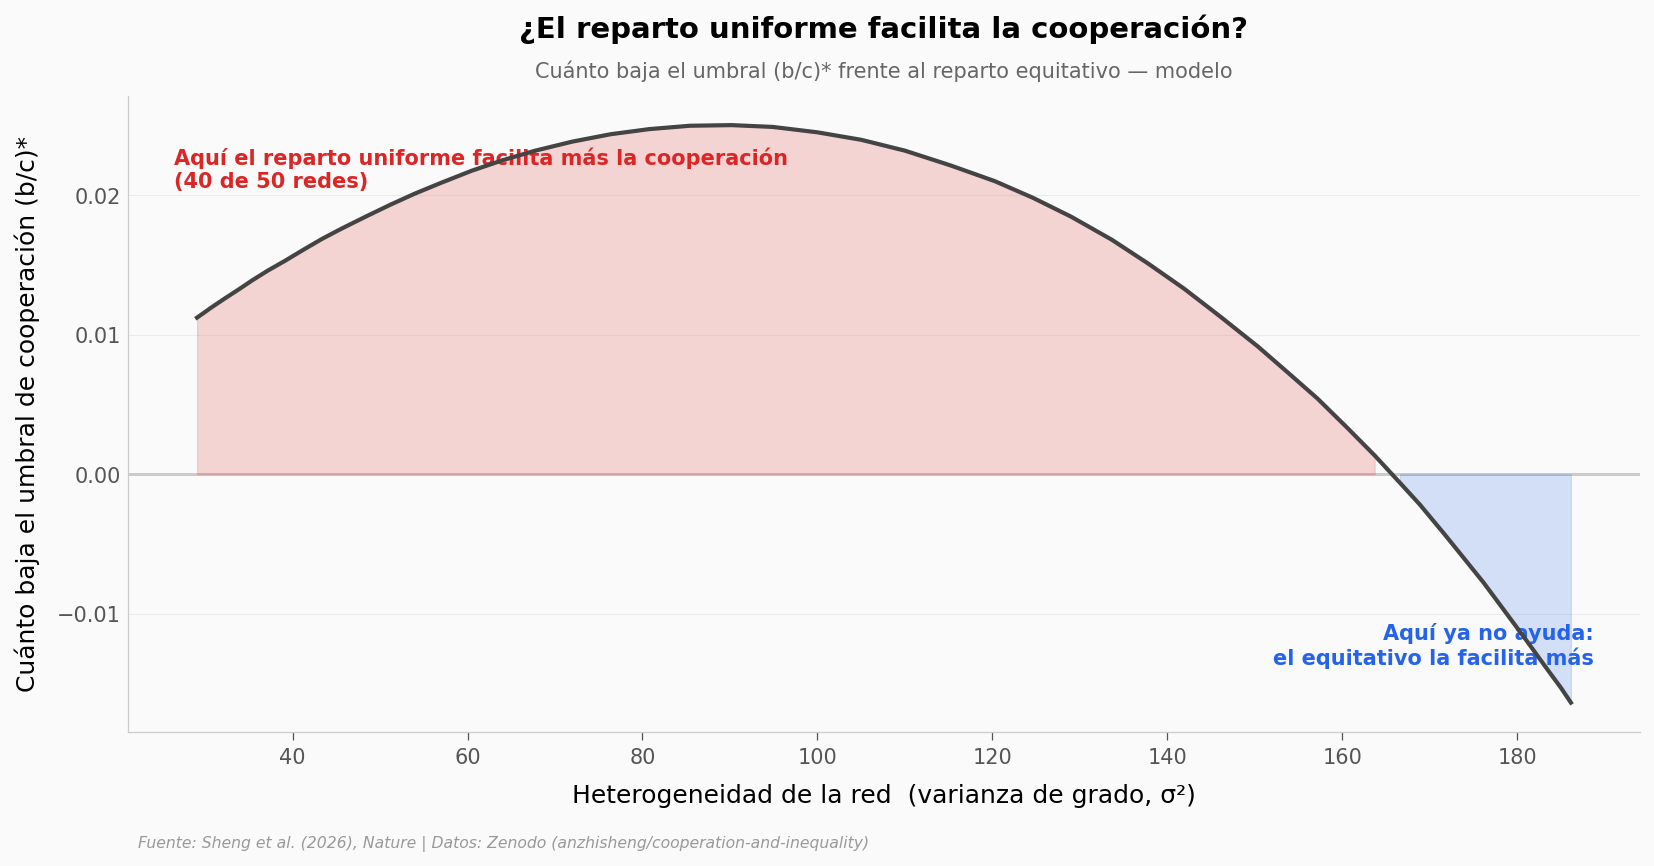

El reparto uniforme baja el umbral en 40/50 redes (80% — coincide con el 'most' del abstract).
Ventaja máxima: 0.0250 en σ²=90.2.
Las diferencias son pequeñas (<2%) y dejan de existir en las redes más heterogéneas.


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = tradeoff.degree_variance
# Cuánto BAJA el umbral el reparto uniforme respecto al equitativo (positivo = ayuda más)
ventaja = tradeoff.equitable_bcr - tradeoff.uniform_bcr

ax.axhline(y=0, color=COLOR_CONTEXTO, linewidth=1.2, linestyle='-', zorder=1)
ax.fill_between(x, 0, ventaja, where=(ventaja >= 0),
                color=COLOR_UNIFORME, alpha=0.18, zorder=2)
ax.fill_between(x, 0, ventaja, where=(ventaja < 0),
                color=COLOR_EQUITATIVA, alpha=0.18, zorder=2)
ax.plot(x, ventaja, color='#444444', linewidth=2.0, zorder=5)

n_ayuda = int((ventaja >= 0).sum())
ax.text(0.03, 0.92, f'Aquí el reparto uniforme facilita más la cooperación\n({n_ayuda} de {len(tradeoff)} redes)',
        transform=ax.transAxes, fontsize=10, color=COLOR_UNIFORME, fontweight='bold', va='top')
ax.text(0.97, 0.10, 'Aquí ya no ayuda:\nel equitativo la facilita más',
        transform=ax.transAxes, fontsize=10, color=COLOR_EQUITATIVA, fontweight='bold',
        ha='right', va='bottom')

ax.set_title('¿El reparto uniforme facilita la cooperación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuánto baja el umbral (b/c)* frente al reparto equitativo — modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Heterogeneidad de la red  (varianza de grado, σ²)')
ax.set_ylabel('Cuánto baja el umbral de cooperación (b/c)*')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ventaja_umbral_cooperacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"El reparto uniforme baja el umbral en {n_ayuda}/{len(tradeoff)} redes "
      f"({100*n_ayuda/len(tradeoff):.0f}% — coincide con el 'most' del abstract).")
print(f"Ventaja máxima: {ventaja.max():.4f} en σ²={tradeoff.degree_variance[ventaja.idxmax()]:.1f}.")
print("Las diferencias son pequeñas (<2%) y dejan de existir en las redes más heterogéneas.")

Ahí está la tensión completa: en la mayoría de las redes, repartir por igual sí facilita un poco más la cooperación. Pero esa ayuda viene con la factura del Gini que vimos antes.

¿Y quién paga esa factura? Para verlo hay que abrir una red por dentro y mirar persona por persona. Tomemos una red dispersa: 50 individuos, casi todos con pocas conexiones y un puñado de nodos muy conectados (*hubs*).

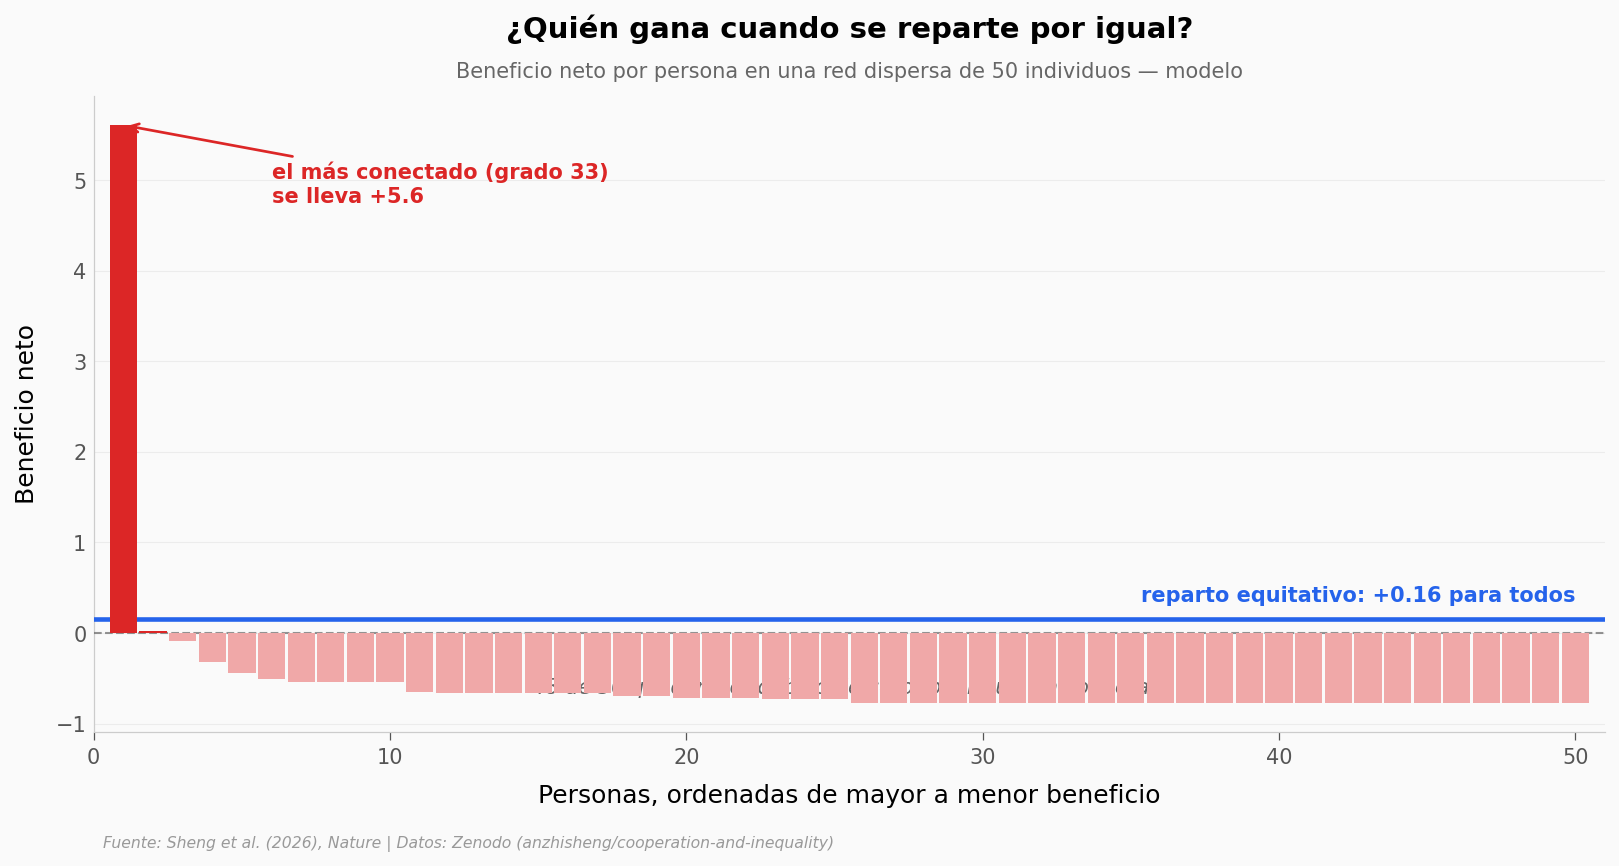

Reparto uniforme: 48/50 personas terminan con beneficio negativo.
El más conectado (grado 33) se lleva +5.61; el reparto equitativo da +0.156 a cada uno.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

eq_val = red_A.payoff_equitativo.iloc[0]  # constante: todos reciben lo mismo
s = red_A.sort_values('payoff_uniforme', ascending=False).reset_index(drop=True)
rank = np.arange(1, len(s) + 1)

# Barra por persona: el que gana (hub) en rojo sólido, los que pierden en rojo claro
bar_colors = [COLOR_UNIFORME if p >= 0 else '#F0A8A8' for p in s.payoff_uniforme]
ax.bar(rank, s.payoff_uniforme, color=bar_colors, width=0.92, zorder=5)
ax.axhline(y=0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.7, zorder=3)
ax.axhline(y=eq_val, color=COLOR_EQUITATIVA, linewidth=2.2, zorder=4)

worse = int((red_A.payoff_uniforme < 0).sum())
grado_hub = int(s.grado.iloc[0])
ax.annotate(f'el más conectado (grado {grado_hub})\nse lleva +{s.payoff_uniforme.iloc[0]:.1f}',
            xy=(1, s.payoff_uniforme.iloc[0]), xytext=(6, s.payoff_uniforme.iloc[0] - 0.4),
            fontsize=10, fontweight='bold', color=COLOR_UNIFORME, va='top',
            arrowprops=dict(arrowstyle='->', color=COLOR_UNIFORME, lw=1.3))
ax.text(len(s), eq_val + 0.15, f'reparto equitativo: +{eq_val:.2f} para todos',
        color=COLOR_EQUITATIVA, fontsize=10, fontweight='bold', ha='right', va='bottom')
ax.text(0.5, 0.06, f'{worse} de {len(red_A)} quedan por debajo de cero (peor que sin cooperar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center', style='italic')

ax.set_title('¿Quién gana cuando se reparte por igual?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Beneficio neto por persona en una red dispersa de 50 individuos — modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Personas, ordenadas de mayor a menor beneficio')
ax.set_ylabel('Beneficio neto')
ax.set_xlim(0, len(s) + 1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/red_dispersa_payoffs.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Reparto uniforme: {worse}/{len(red_A)} personas terminan con beneficio negativo.")
print(f"El más conectado (grado {grado_hub}) se lleva +{red_A.payoff_uniforme.max():.2f}; "
      f"el reparto equitativo da +{eq_val:.3f} a cada uno.")

Casi todos terminan perdiendo y un solo nodo se lleva el premio gordo. El reparto equitativo, en cambio, deja a las 50 personas exactamente iguales.

¿Qué tan concentrado queda ese beneficio? Una última mirada a cómo se distribuye.

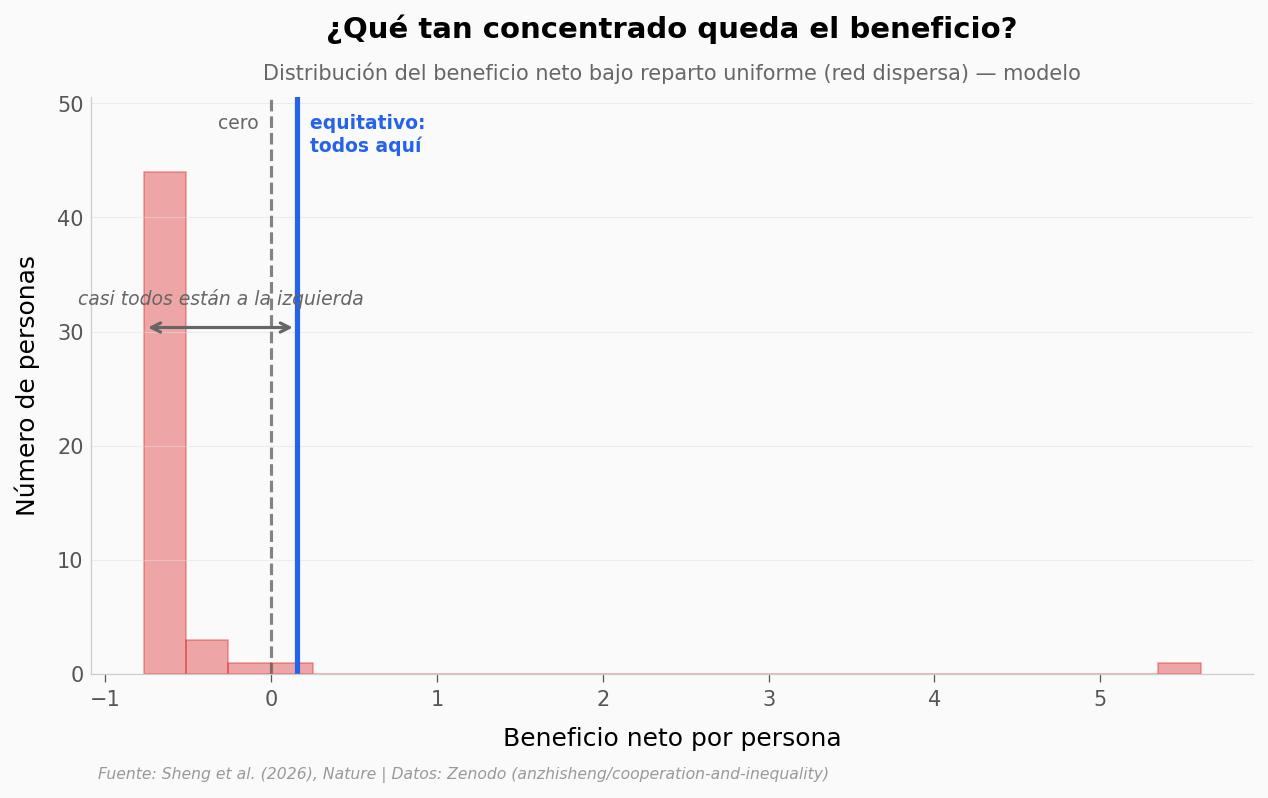

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = red_A.payoff_uniforme.values
eq_val = red_A.payoff_equitativo.iloc[0]

n, bins, patches = ax.hist(data, bins=25, color=COLOR_UNIFORME, alpha=0.4,
                           edgecolor=COLOR_UNIFORME, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=0, color='#666666', linewidth=1.5, linestyle='--', alpha=0.8)
ax.axvline(x=eq_val, color=COLOR_EQUITATIVA, linewidth=2.5)

ax.annotate('', xy=(eq_val, y_max*0.6), xytext=(data.min(), y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((eq_val + data.min())/2, y_max*0.64, 'casi todos están a la izquierda',
        fontsize=9, color='#666666', ha='center', style='italic')
ax.text(eq_val, y_max*0.97, '  equitativo:\n  todos aquí',
        color=COLOR_EQUITATIVA, fontsize=9, fontweight='bold', va='top')
ax.text(0, y_max*0.97, 'cero  ', color='#666666', fontsize=9, ha='right', va='top')

ax.set_title('¿Qué tan concentrado queda el beneficio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del beneficio neto bajo reparto uniforme (red dispersa) — modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Beneficio neto por persona')
ax.set_ylabel('Número de personas')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_beneficio.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El reparto equitativo mantiene el beneficio igualado (Gini ≈ 0) | ✅ | Gini máximo 1,3×10⁻¹⁶ en las 50 redes — cero a efectos prácticos. |
| El reparto uniforme concentra más el beneficio cuanto más heterogénea es la red | ✅ | Gini sube de 0,10 a 0,33 (3,3×) con la varianza de grado. |
| Repartir por igual facilita la cooperación "en la mayoría" de las redes | ✅ | Baja el umbral (b/c)\* en 40 de 50 redes (80%) — coincide con "most" del abstract. |
| Esa ventaja para cooperar es grande | ⚠️ | Diferencias <2% y no monótonas: en las 10 redes más heterogéneas el uniforme ya no ayuda. El contraste fuerte es el Gini, no el umbral. |
| Bajo reparto uniforme casi todos quedan peor que sin cooperar | ⚠️ | Cierto en la red dispersa de ejemplo (48/50 negativos); en la red densa nadie queda negativo, pero el Gini del beneficio sigue alto. Es un ejemplo ilustrativo, no una ley universal. |
| La desigualdad es una consecuencia inevitable de la cooperación | ❌ | El paper lo enmarca como posibilidad (*may be an unavoidable consequence*), no como hecho. Decimos "podría ser". |

> **Limitaciones:** es un **modelo teórico**. Los mecanismos son causales solo dentro del modelo — no son una medición de sociedades humanas reales. Los ejemplos de red dispersa/densa son ilustrativos. Las diferencias de umbral entre reglas son pequeñas; lo robusto es el contraste de igualdad (Gini).

### Ahora tú

1. **¿En qué redes el reparto uniforme deja de ayudar?** Filtra `tradeoff` donde `uniform_bcr > equitable_bcr` y mira el rango de heterogeneidad. *Pista:* `tradeoff[tradeoff.uniform_bcr > tradeoff.equitable_bcr]`.

2. **¿El hub siempre gana?** En la red densa (`red_B`), ¿cuántas personas quedan por debajo del reparto equitativo bajo el esquema uniforme? *Pista:* compara `red_B.payoff_uniforme` con `red_B.payoff_equitativo.iloc[0]`.

3. **¿Y si midieras la igualdad con otra vara?** Calcula la diferencia entre el que más gana y el que menos gana (rango) en cada red de ejemplo bajo reparto uniforme. ¿Cuál es más desigual?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿en qué redes el reparto uniforme YA NO facilita la cooperación?
deja_de_ayudar = tradeoff[tradeoff.uniform_bcr > tradeoff.equitable_bcr]
print(f"El reparto uniforme deja de ayudar en {len(deja_de_ayudar)} de {len(tradeoff)} redes.")
if len(deja_de_ayudar):
    print(f"Ocurre solo en las más heterogéneas: σ² desde {deja_de_ayudar.degree_variance.min():.1f} "
          f"hasta {deja_de_ayudar.degree_variance.max():.1f}.")

# Pregunta 2: en la red densa, ¿cuántos quedan por debajo del equitativo bajo uniforme?
eq_B = red_B.payoff_equitativo.iloc[0]
peor = int((red_B.payoff_uniforme < eq_B).sum())
print(f"\nRed densa: {peor}/{len(red_B)} personas reciben menos bajo uniforme que bajo equitativo "
      f"(equitativo = +{eq_B:.3f} para todos).")

El reparto uniforme deja de ayudar en 10 de 50 redes.
Ocurre solo en las más heterogéneas: σ² desde 166.6 hasta 186.1.

Red densa: 45/50 personas reciben menos bajo uniforme que bajo equitativo (equitativo = +0.867 para todos).


## Fuentes

## Fuentes

**Paper**: [Cooperation conflicts with equality when allocating public goods](https://doi.org/10.1038/s41586-026-10550-3)  
*Nature, 2026-06-03*

**Dataset canónico**: [anzhisheng/cooperation-and-inequality: v1.0.2 (source data + simulation code)](https://doi.org/10.5281/zenodo.19166894)  
*Zenodo — código de simulación + datos fuente*

*15 afirmaciones del notebook verificadas contra estas fuentes*